# Time Series Exercises


In [1]:
import pandas as pd

%matplotlib inline

# Taming time series

Time series are collections of points collected at successive times, usually with equal time intervals between them.

## Exercise: Importing and visualising Time Series data

In this module, we will consider the "bikes" dataset again but this time taking a time-series perspective. 

* Load the data `bikes.csv`
* Specify that you want to parse the column `'date'` as dates using `parse_dates=['date']` and
* Use the dates as the index column

Check with `.head()` that everything looks fine

In [2]:
# Your code here

bikes = pd.read_csv("data/bikes.csv", parse_dates=["date"], index_col="date")
bikes.head()


,temperature,humidity,windspeed,count
date,,,,
2011-01-03,2.716070,45.715346,21.414957,120.0
2011-01-04,2.896673,54.267219,15.136882,108.0
2011-01-05,4.235654,45.697702,17.034578,82.0
2011-01-06,3.112643,50.237349,10.091568,88.0
2011-01-07,2.723918,49.144928,15.738204,148.0


### Exercise: display all time series

Display the time series (you can either use `pandas` plotting facility by doing `.plot(...)` or use `matplotlib` directly)

<Axes: xlabel='date'>

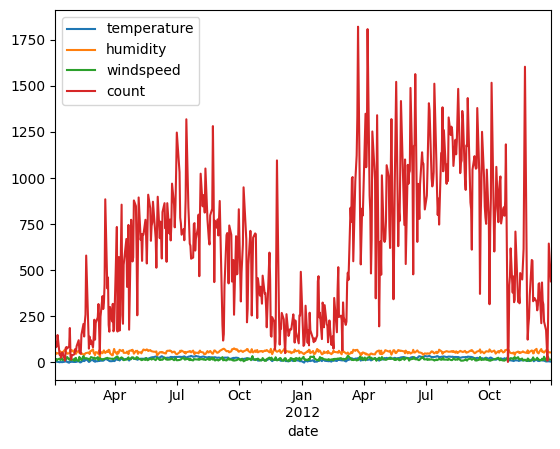

In [3]:
# Your code here

bikes.plot()


### Exercise: only plot the temperature 


<Axes: xlabel='date'>

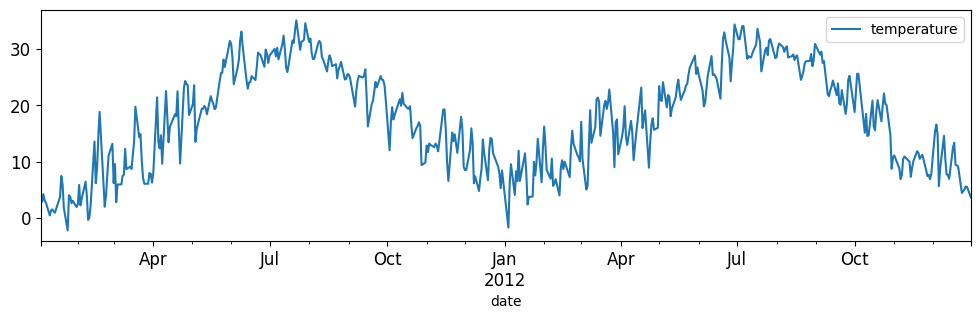

In [4]:
# Your code here
bikes.plot(y="temperature", figsize=(12, 3), fontsize=12)


### Exercise: Number of bikes in a given month

From the chart above, you can see that the data covers two years and that there is a similar pattern in both years which is to be expected for the temperatures. 

The data can be queried according to dates. 

Aggregate the data from January 2012 and check the sum of bikes hired that month. Compare this value with the number of bikes hired in August 2012.

In [5]:
jan_start = pd.Timestamp("1st January 2012")
jan_end = pd.Timestamp("31st January 2012")
bikes_jan = bikes[jan_start:jan_end]["count"].sum()

# Your code here
aug_start = pd.Timestamp(2012, 8, 1)
aug_end = pd.Timestamp(2012, 8, 31)
bikes_aug = bikes[aug_start:aug_end]["count"].sum()

print(
    "{0:.0f} bikes in January vs {1:.0f} bikes in August.".format(
        bikes_jan, bikes_aug
    )
)


5939 bikes in January vs 37025 bikes in August.


### Exercise: Exploring stationarity

Consider the temperature data within the bikes dataframe. 

1. By eye, do you think this is a stationary time series? 
2. Use the Augmented Dickey Fuller test (adfuller) to decide. 

In [6]:
from statsmodels.tsa.stattools import adfuller


# Your code here
def testStationarity(x, alpha=0.05):
    results = adfuller(x)
    pvalue = results[1]
    if pvalue < alpha:
        return "Reject the null: the time series is stationary"
    else:
        return "Accept the null: the time series is non-stationary"


testStationarity(bikes.temperature)


'Accept the null: the time series is non-stationary'

### Exercise: Explore autocorrelation

Using the bikes dataset, use the autocorrelation and partial autocorrelation functions to explore up to 15 lags

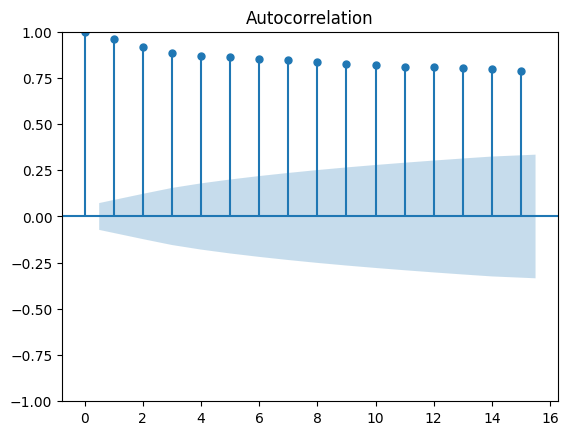

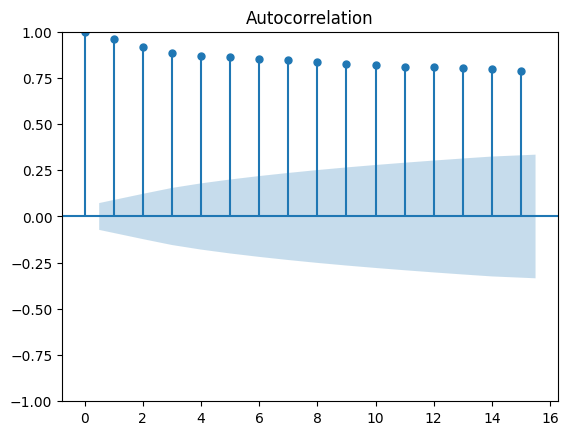

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Your code here
plot_acf(bikes.temperature, lags=15)


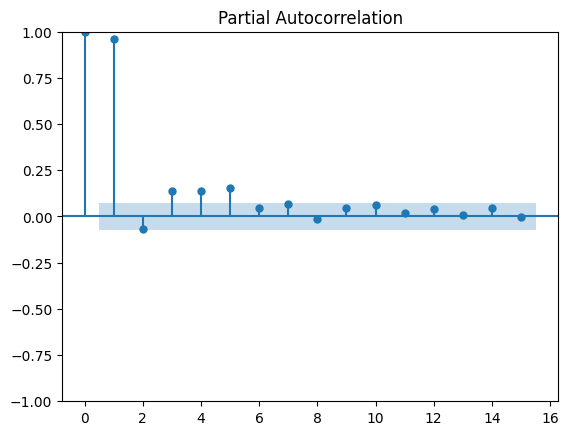

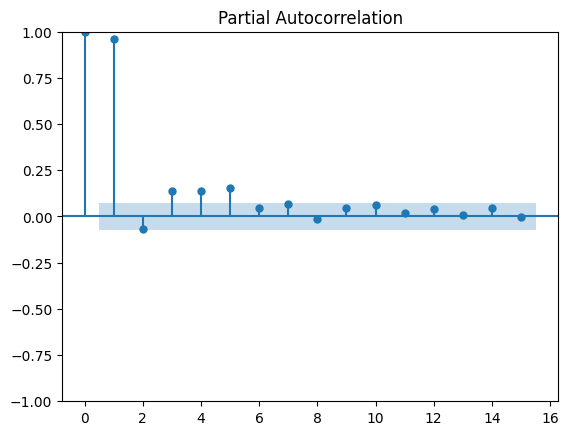

In [8]:
# Your code here
plot_pacf(bikes.temperature, method="ywm", lags=15)


Notice importantly that here, by eye we can see a potential annual seasonality in the data, however as we only have 2 years of data, recorded at a daily frequency, we'd need to increase the number of lags significantly in order to see this behaviour in the autocorrelation. As we can only compute partial correlations for lags up to 50% of the sample size, in this case, we'd have to collect more observations. Alternatively we can code the partial autocorrelation ourselves, however the accuracy decreases when using a large number (relative to the length of the series) for the lags. 